In [1]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

In [2]:
kmax = 64
zsize = 18.074844397670482
dz = zsize / kmax
z = np.linspace(0.5*dz, zsize-0.5*dz, kmax)
zstart=0
zend=int(3*kmax/4)

save=True

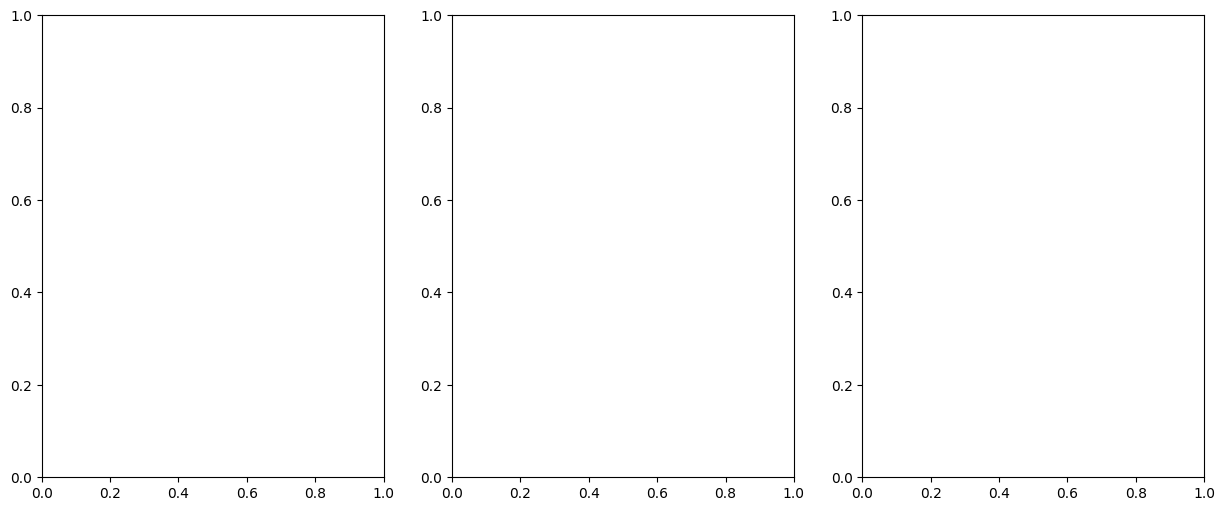

In [3]:
# del(fig,ax)
fig,ax = plt.subplots(1,3,figsize = (15,6));

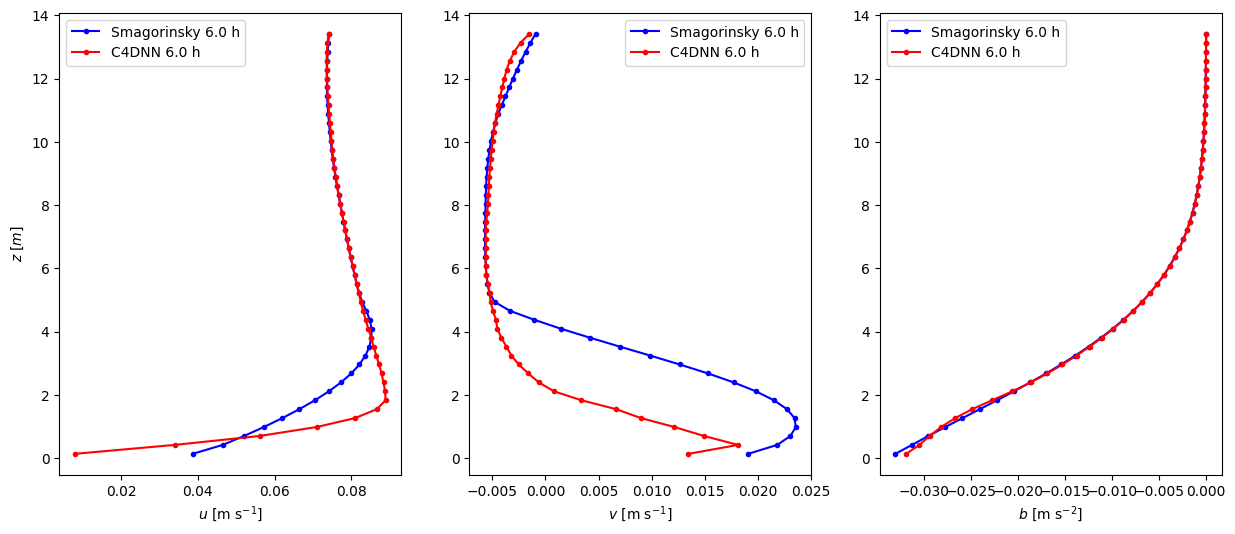

In [4]:
paths=['../cases/SBL_Smag/','../cases/SBL_DNN/']
pathLabels=['Smagorinsky','C4DNN']
colors=['Blue','Red']
varStrings=['u','v','b']
varLabelStrings=[r'$u$ [m s$^{-1}$]',r'$v$ [m s$^{-1}$]',r'$b$ [m s$^{-2}$]']
itimes=[-1]

for ifile in range(len(paths)): #tdqm notebook just draws progress bar
    file=paths[ifile]+'SBL2700.default.0000000.nc'

    stats = nc.Dataset(file, 'r')
    default = stats.groups['default']
    thermo = stats.groups['thermo']

    z = stats.variables['z'][:]
        
    for iv,varStr in enumerate(varStrings):

        for it,itime in enumerate(itimes):
            try:
                var=thermo.variables[varStr][itime, :]
            except:
                var=default.variables[varStr][itime, :]
            t = stats.variables['time'][itime]
            
            ax[iv].plot(var[zstart:zend], z[zstart:zend],'.-',color=colors[ifile],label=pathLabels[ifile]+' '+str(np.round(t/60/60,decimals=1))+' h')
        ax[iv].legend()
        ax[iv].set_xlabel(varLabelStrings[iv])#r'$b [m^2 s^{-2}]$')

    ax[0].set_ylabel(r'$z \; [m]$')

fig

In [5]:
# save=True
if save:
    plt.figure(fig)
    fmts=["png","eps"]
    for fmt in fmts:
        plt.savefig("Profile_longTime."+fmt, format=fmt)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
